# Your Editing DNA: A Visual Style Analysis

**Goal:** Visualize and understand your personal editing style across 287 paired photos. This notebook reads the style profiles extracted by Pipelines 02-03 and turns them into interpretable visualizations.

**What you'll see:**
1. **Global tendencies** — how you shift exposure, shadows, highlights, temperature on average
2. **Scene-specific signatures** — how your editing changes for night streets vs portraits vs landscapes
3. **Tone curve fingerprint** — your characteristic S-curve shape per region
4. **Color DNA** — which hues you push, pull, and leave alone (the 8-channel HSL mixer)
5. **Consistency analysis** — which parameters you're decisive about vs which vary widely
6. **Region-specific behavior** — how you treat sky vs subject vs background differently

**Depends on:** Checkpoints from Pipelines 02-03. No GPU needed — this is pure visualization.

**Future:** These visualizations become the "Your Style Profile" dashboard in the web UI (Pipeline 05+). Minimum 10 uploaded pairs for a new user to generate their profile.

In [1]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/photo-style-rl'
CHECKPOINTS = f'{PROJECT}/checkpoints'

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

# Color palette that matches a photography/film aesthetic
PALETTE = {
    'warm': '#E8913A',
    'cool': '#4A90D9',
    'neutral': '#8B8B8B',
    'accent': '#D94A4A',
    'bg': '#1A1A1A',
    'text': '#E0E0E0',
    'grid': '#333333',
}

# Load all available style data
data = {}

files_to_load = {
    'llm_profiles': 'style_profiles_llm.json',       # Per-scene LLM estimates (NB02)
    'math_profile': 'simon_math_profile.json',        # Per-region pixel math (NB02)
    'color_profile': 'simon_advanced_color_profile.json',  # Tone curves + HSL (NB03)
    'raw_analyses': 'style_profile_analyses.json',    # Individual image analyses (NB02)
}

for key, filename in files_to_load.items():
    path = f'{CHECKPOINTS}/{filename}'
    try:
        with open(path, 'r') as f:
            data[key] = json.load(f)
        print(f"Loaded {key}: {filename}")
    except FileNotFoundError:
        print(f"Missing {filename} — run Pipeline {'02' if 'math' in key or 'llm' in key or 'raw' in key else '03'} first")
        data[key] = None

# Quick summary
if data['raw_analyses']:
    print(f"\nAnalyzed {len(data['raw_analyses'])} individual images")
if data['math_profile']:
    print(f"Mathematical profiles for {len(data['math_profile'])} region types: {list(data['math_profile'].keys())}")
if data['color_profile']:
    print(f"Advanced color profiles for {len(data['color_profile'])} region types: {list(data['color_profile'].keys())}")

Mounted at /content/drive
Loaded llm_profiles: style_profiles_llm.json
Loaded math_profile: simon_math_profile.json
Loaded color_profile: simon_advanced_color_profile.json
Loaded raw_analyses: style_profile_analyses.json

Analyzed 30 individual images
Mathematical profiles for 12 region types: ['ground', 'subject', 'background', 'highlight_area', 'clothing', 'sky', 'building', 'shadow_area', 'face', 'hair', 'foliage', 'water']
Advanced color profiles for 11 region types: ['ground', 'subject', 'background', 'highlight_area', 'clothing', 'sky', 'building', 'shadow_area', 'face', 'foliage', 'water']


## 1. Your Global Editing Signature

These are the parameters you consistently adjust across all photos, regardless of scene type. Think of this as your "default preset" — the starting point before any scene-specific adjustments.

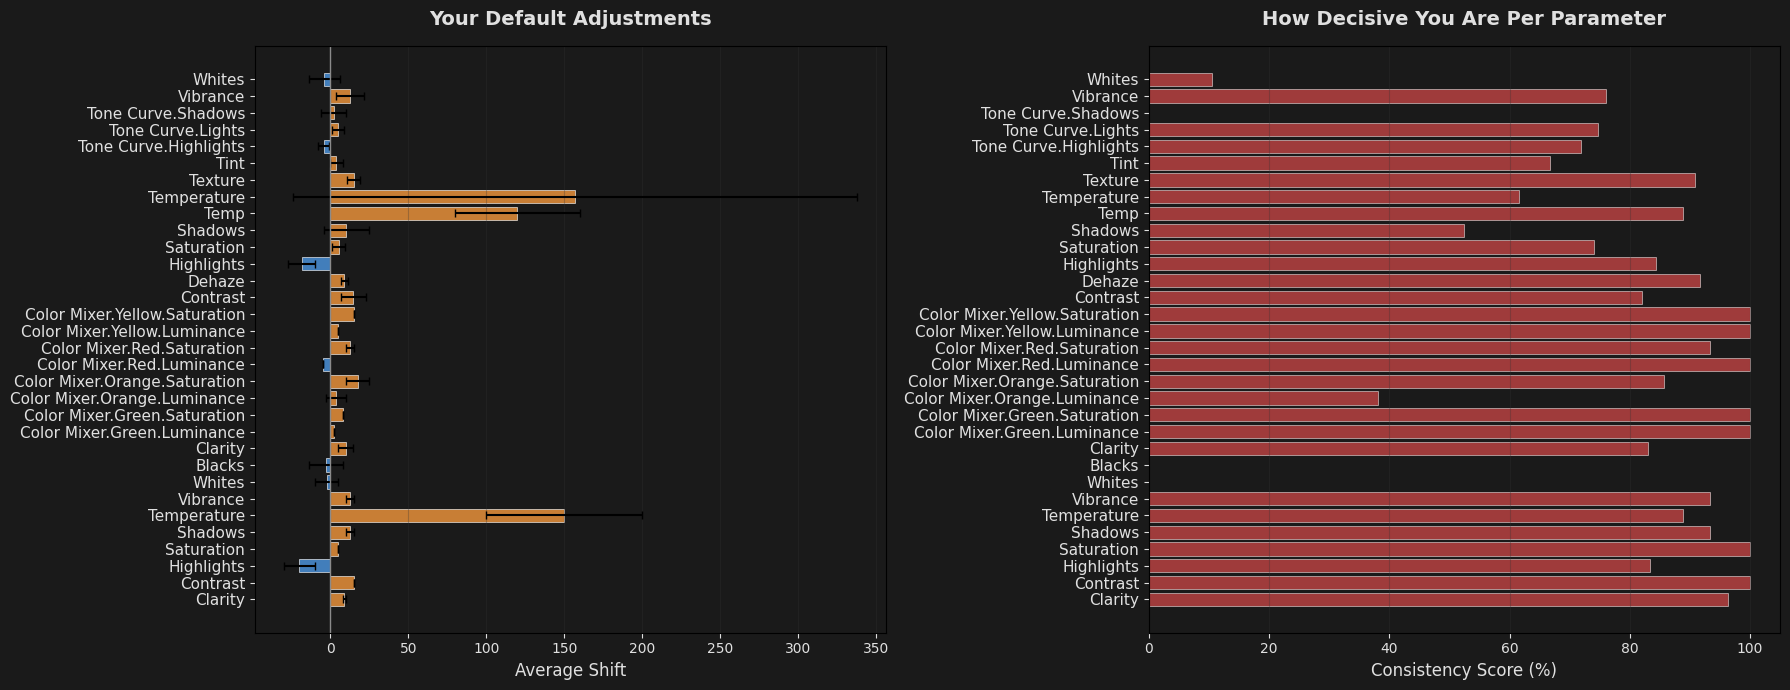


📸 Your Editing Signature:
  • You variably increase temperature by 157.1
  • You consistently increase Temperature by 150.0
  • You consistently increase temp by 120.0
  • You variably decrease Highlights by 20.0
  • You consistently decrease highlights by 18.3


In [2]:
# Global tendency radar chart and bar chart
# Pull the overall style from the LLM-estimated profiles
if data['llm_profiles'] and 'overall' in data['llm_profiles']:
    overall = data['llm_profiles']['overall']

    # Filter to params with meaningful shifts (|mean| > 1)
    params = {k: v for k, v in overall.items() if isinstance(v, dict) and abs(v.get('mean', 0)) > 1}

    if params:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor=PALETTE['bg'])

        # --- Left: Horizontal bar chart of mean shifts ---
        ax1.set_facecolor(PALETTE['bg'])
        names = list(params.keys())
        means = [params[k]['mean'] for k in names]
        stds = [params[k].get('std', 0) for k in names]

        # Color bars by direction: warm/positive = orange, cool/negative = blue
        colors = [PALETTE['warm'] if m > 0 else PALETTE['cool'] for m in means]

        y_pos = range(len(names))
        bars = ax1.barh(y_pos, means, xerr=stds, color=colors, alpha=0.85,
                        edgecolor='white', linewidth=0.5, capsize=3, error_kw={'color': PALETTE['neutral']})
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels([n.replace('_', ' ').title() for n in names], color=PALETTE['text'], fontsize=11)
        ax1.axvline(0, color=PALETTE['neutral'], linewidth=1, linestyle='-')
        ax1.set_xlabel('Average Shift', color=PALETTE['text'], fontsize=12)
        ax1.set_title('Your Default Adjustments', color=PALETTE['text'], fontsize=14, fontweight='bold', pad=15)
        ax1.tick_params(colors=PALETTE['text'])
        ax1.grid(axis='x', color=PALETTE['grid'], alpha=0.3)

        # --- Right: Consistency gauge (lower std = more decisive) ---
        ax2.set_facecolor(PALETTE['bg'])
        # Coefficient of variation: std / |mean| — lower = more consistent
        consistency = []
        for k in names:
            m = abs(params[k]['mean'])
            s = params[k].get('std', 0)
            cv = s / m if m > 0 else float('inf')
            consistency.append(min(cv, 3.0))  # cap for display

        # Invert so higher bar = more consistent
        max_cv = max(consistency) if consistency else 1
        consistency_score = [(max_cv - c) / max_cv * 100 for c in consistency]

        bars2 = ax2.barh(y_pos, consistency_score, color=PALETTE['accent'], alpha=0.7,
                         edgecolor='white', linewidth=0.5)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels([n.replace('_', ' ').title() for n in names], color=PALETTE['text'], fontsize=11)
        ax2.set_xlabel('Consistency Score (%)', color=PALETTE['text'], fontsize=12)
        ax2.set_title('How Decisive You Are Per Parameter', color=PALETTE['text'], fontsize=14, fontweight='bold', pad=15)
        ax2.tick_params(colors=PALETTE['text'])
        ax2.grid(axis='x', color=PALETTE['grid'], alpha=0.3)
        ax2.set_xlim(0, 105)

        plt.tight_layout()
        plt.show()

        # Plain-english summary
        print("\n📸 Your Editing Signature:")
        sorted_params = sorted(params.items(), key=lambda x: abs(x[1]['mean']), reverse=True)
        for name, stats in sorted_params[:5]:
            direction = "increase" if stats['mean'] > 0 else "decrease"
            consistency_word = "consistently" if stats.get('std', 0) < abs(stats['mean']) * 0.5 else "variably"
            print(f"  • You {consistency_word} {direction} {name.replace('_', ' ')} by {abs(stats['mean']):.1f}")
else:
    print("No LLM profiles found. Run Pipeline 02 first.")

## 2. Scene-Specific Signatures

Your editing style isn't uniform, meaning sometimes you treat night street scenes differently from golden hour landscapes. This shows how your adjustments shift by scene type.

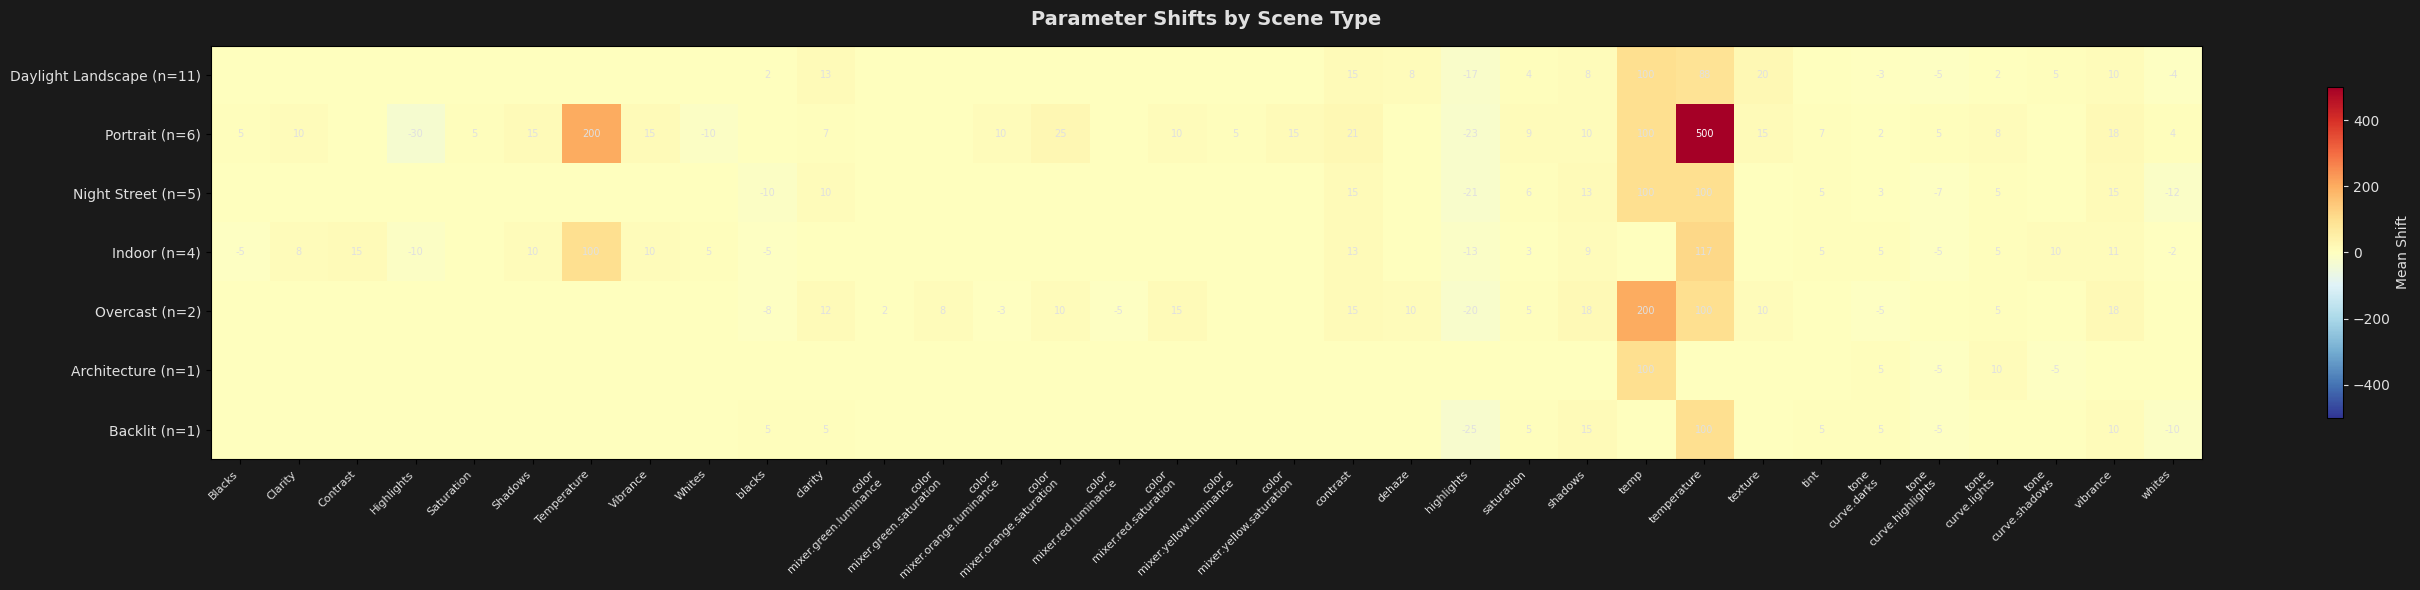


🎬 Scene-Specific Insights:
  Daylight Landscape: temp +100, temperature +88, texture +20
  Portrait: temperature +500, Temperature +200, temp +100
  Night Street: temperature +100, temp +100, highlights -21
  Indoor: temperature +117, Temperature +100, Contrast +15


In [3]:
# Scene heatmap
if data['llm_profiles'] and 'by_scene' in data['llm_profiles']:
    scenes = data['llm_profiles']['by_scene']

    # Collect all param names across scenes
    all_params = set()
    for scene_data in scenes.values():
        all_params.update(scene_data.get('params', {}).keys())
    all_params = sorted(all_params)

    # Build the matrix: rows = scenes, cols = params
    scene_names = sorted(scenes.keys(), key=lambda s: -scenes[s].get('count', 0))
    matrix = np.zeros((len(scene_names), len(all_params)))

    for i, scene in enumerate(scene_names):
        for j, param in enumerate(all_params):
            stats = scenes[scene].get('params', {}).get(param, {})
            matrix[i, j] = stats.get('mean', 0) if isinstance(stats, dict) else 0

    fig, ax = plt.subplots(figsize=(max(14, len(all_params) * 0.8), max(6, len(scene_names) * 0.6)),
                           facecolor=PALETTE['bg'])
    ax.set_facecolor(PALETTE['bg'])

    # Diverging colormap: blue = negative shifts, orange = positive
    vmax = max(abs(matrix.min()), abs(matrix.max()), 1)
    im = ax.imshow(matrix, cmap='RdYlBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

    # Labels
    param_labels = [p.replace('_', '\n').replace('tone curve.', 'TC:').replace('color mixer.', 'CM:')
                    for p in all_params]
    ax.set_xticks(range(len(all_params)))
    ax.set_xticklabels(param_labels, rotation=45, ha='right', color=PALETTE['text'], fontsize=8)
    ax.set_yticks(range(len(scene_names)))

    # Include count in label so you know how many photos each scene type has
    scene_labels = [f"{s.replace('_', ' ').title()} (n={scenes[s].get('count', '?')})" for s in scene_names]
    ax.set_yticklabels(scene_labels, color=PALETTE['text'], fontsize=10)

    ax.set_title('Parameter Shifts by Scene Type', color=PALETTE['text'], fontsize=14, fontweight='bold', pad=15)

    # Annotate cells with values
    for i in range(len(scene_names)):
        for j in range(len(all_params)):
            val = matrix[i, j]
            if abs(val) > 1:
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        color='white' if abs(val) > vmax * 0.5 else PALETTE['text'], fontsize=7)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Mean Shift', color=PALETTE['text'])
    cbar.ax.yaxis.set_tick_params(color=PALETTE['text'])
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=PALETTE['text'])

    plt.tight_layout()
    plt.show()

    # Narrative
    print("\n🎬 Scene-Specific Insights:")
    for scene in scene_names[:4]:
        scene_params = scenes[scene].get('params', {})
        top_shifts = sorted(scene_params.items(),
                           key=lambda x: abs(x[1].get('mean', 0)) if isinstance(x[1], dict) else 0,
                           reverse=True)[:3]
        shifts_str = ", ".join([f"{k.replace('_', ' ')} {v['mean']:+.0f}" for k, v in top_shifts if isinstance(v, dict)])
        print(f"  {scene.replace('_', ' ').title()}: {shifts_str}")
else:
    print("No scene-specific profiles found.")

## 3. Your Tone Curve Fingerprint

The tone curve is arguably the most distinctive part of any photographer's style. It controls how shadows, midtones, and highlights map to output brightness. Your characteristic S-curve (or lack thereof) defines the "feel" of your images.

Each line below represents a different semantic region — you may treat sky highlights differently from subject shadows.

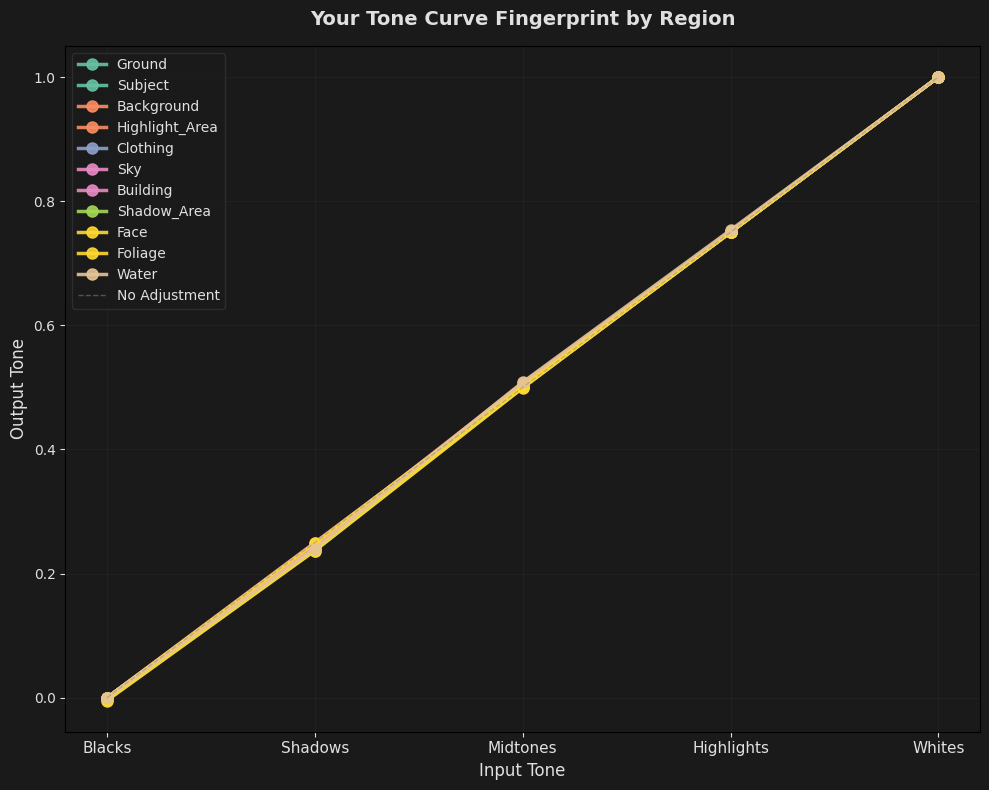


🎞️ Tone Curve Insights:
  Ground: relatively neutral curve
    Shadows: -3.1  |  Highlights: +0.0
  Subject: relatively neutral curve
    Shadows: -2.5  |  Highlights: +0.0
  Background: relatively neutral curve
    Shadows: -1.5  |  Highlights: +0.0
  Highlight_Area: relatively neutral curve
    Shadows: -2.5  |  Highlights: +0.0
  Clothing: relatively neutral curve
    Shadows: -1.6  |  Highlights: +0.0
  Sky: relatively neutral curve
    Shadows: +0.0  |  Highlights: +0.0
  Building: relatively neutral curve
    Shadows: -2.2  |  Highlights: +0.0
  Shadow_Area: relatively neutral curve
    Shadows: -4.2  |  Highlights: +0.0
  Face: relatively neutral curve
    Shadows: -0.4  |  Highlights: +0.0
  Foliage: relatively neutral curve
    Shadows: -4.3  |  Highlights: +0.0
  Water: relatively neutral curve
    Shadows: -3.2  |  Highlights: +1.1


In [4]:
# Tone curve visualization
if data['color_profile']:
    regions_with_curves = {r: d['tone_curve'] for r, d in data['color_profile'].items()
                          if 'tone_curve' in d and isinstance(d['tone_curve'], dict)}

    if regions_with_curves:
        fig, ax = plt.subplots(figsize=(10, 8), facecolor=PALETTE['bg'])
        ax.set_facecolor(PALETTE['bg'])

        bands = ['blacks', 'shadows', 'midtones', 'highlights', 'whites']
        band_positions = [0, 0.25, 0.5, 0.75, 1.0]  # normalized x-axis

        # Color each region distinctly
        region_colors = plt.cm.Set2(np.linspace(0, 0.8, len(regions_with_curves)))

        for idx, (region, curve) in enumerate(regions_with_curves.items()):
            shifts = [curve.get(b, 0) for b in bands]

            # The "output" is the identity (input=output) plus the shift
            # This mimics how a Lightroom tone curve looks
            output = [pos + shift / 100.0 * 0.3 for pos, shift in zip(band_positions, shifts)]

            ax.plot(band_positions, output, 'o-', color=region_colors[idx],
                    linewidth=2.5, markersize=8, label=region.title(), alpha=0.9)

        # Draw the identity line (no adjustment = this diagonal)
        ax.plot([0, 1], [0, 1], '--', color=PALETTE['neutral'], linewidth=1, alpha=0.5, label='No Adjustment')

        ax.set_xticks(band_positions)
        ax.set_xticklabels([b.title() for b in bands], color=PALETTE['text'], fontsize=11)
        ax.set_xlabel('Input Tone', color=PALETTE['text'], fontsize=12)
        ax.set_ylabel('Output Tone', color=PALETTE['text'], fontsize=12)
        ax.set_title('Your Tone Curve Fingerprint by Region', color=PALETTE['text'],
                     fontsize=14, fontweight='bold', pad=15)
        ax.tick_params(colors=PALETTE['text'])
        ax.grid(True, color=PALETTE['grid'], alpha=0.3)
        ax.legend(facecolor=PALETTE['bg'], edgecolor=PALETTE['grid'],
                  labelcolor=PALETTE['text'], fontsize=10)

        plt.tight_layout()
        plt.show()

        # Interpretation
        print("\n🎞️ Tone Curve Insights:")
        for region, curve in regions_with_curves.items():
            shadow_shift = curve.get('shadows', 0)
            highlight_shift = curve.get('highlights', 0)

            if shadow_shift > 5 and highlight_shift < -5:
                style = "classic film look (lifted shadows + compressed highlights)"
            elif shadow_shift < -5 and highlight_shift > 5:
                style = "high contrast (crushed shadows + bright highlights)"
            elif shadow_shift > 5:
                style = "faded/matte look (lifted shadows)"
            elif highlight_shift < -5:
                style = "soft rolloff (compressed highlights)"
            else:
                style = "relatively neutral curve"

            print(f"  {region.title()}: {style}")
            print(f"    Shadows: {shadow_shift:+.1f}  |  Highlights: {highlight_shift:+.1f}")
    else:
        print("No tone curve data found in the advanced profile.")
else:
    print("No advanced color profile found. Run Pipeline 03 first.")

## 4. Color DNA: Your 8-Channel HSL Signature

This is the most granular view of your color preferences. For each of 8 color channels (reds through magentas), we see how you shift the hue, saturation, and luminance. This is what gives your photos their distinctive "color science."

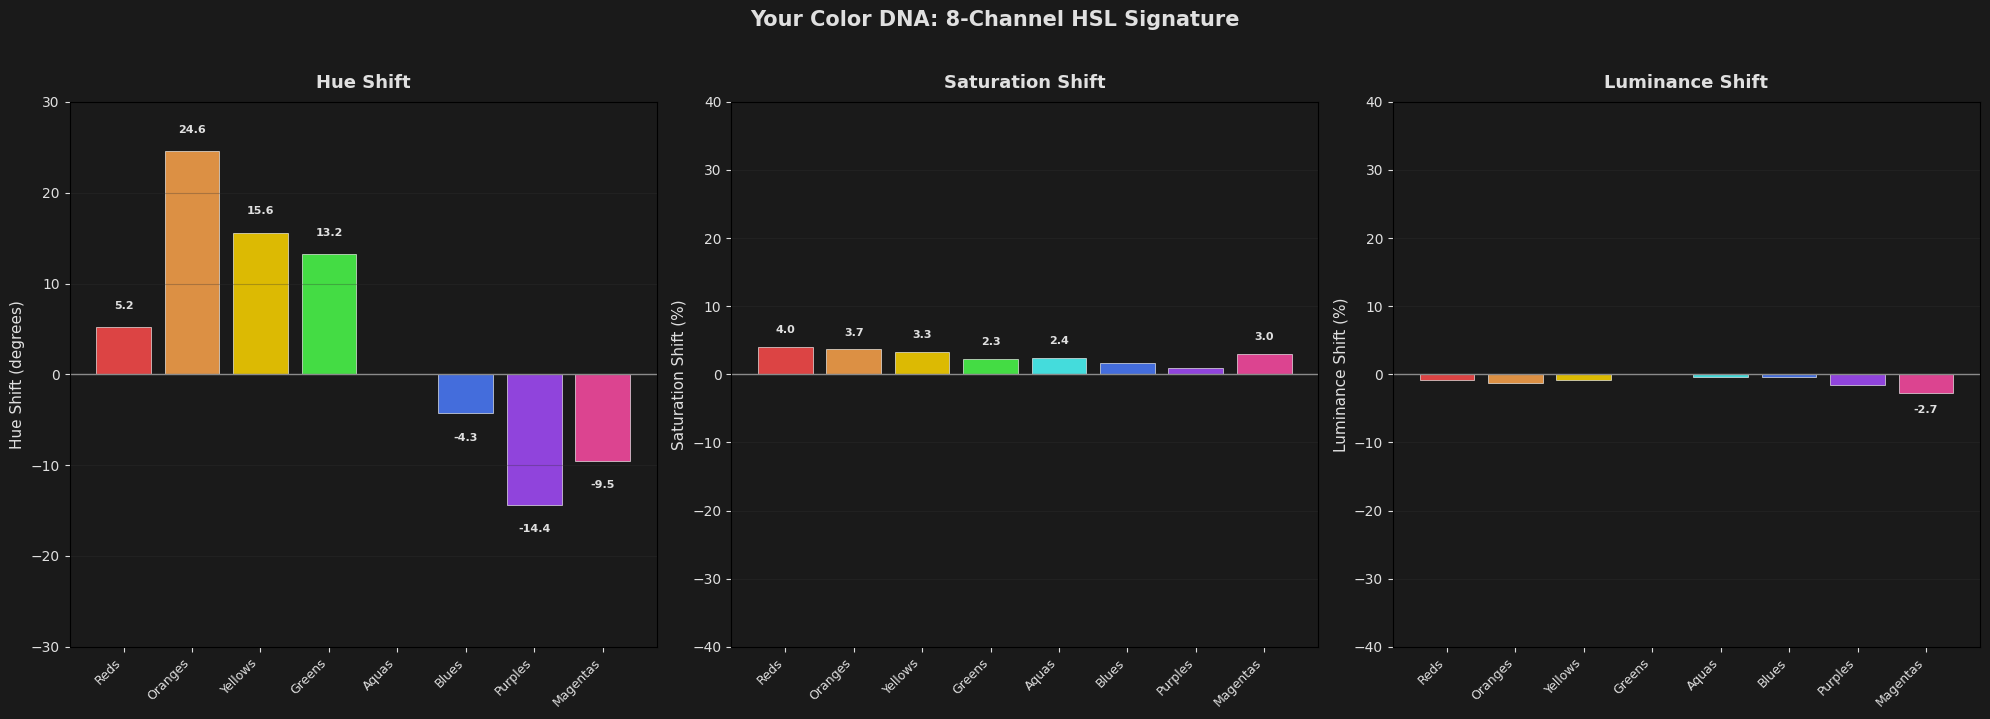


🎨 Color Insights:
  Reds: hue shifted +5.2°, saturation boosted by 4.0%
  Oranges: hue shifted +24.6°, saturation boosted by 3.7%
  Yellows: hue shifted +15.6°, saturation boosted by 3.3%
  Greens: hue shifted +13.2°
  Blues: hue shifted -4.3°
  Purples: hue shifted -14.4°
  Magentas: hue shifted -9.5°

  💡 Boosted orange saturation — common in warm/golden hour aesthetics


In [5]:
# HSL mixer polar/bar visualization
if data['color_profile']:
    # Aggregate HSL data across all regions
    all_colors = ['reds', 'oranges', 'yellows', 'greens', 'aquas', 'blues', 'purples', 'magentas']
    color_hex = ['#FF4C4C', '#FFA64C', '#FFD700', '#4CFF4C', '#4CFFFF', '#4C7CFF', '#A64CFF', '#FF4CA6']

    # Collect shifts across all profiled regions
    aggregated = {c: {'h': [], 's': [], 'l': []} for c in all_colors}
    for region, profile in data['color_profile'].items():
        mixer = profile.get('color_mixer', {})
        if not isinstance(mixer, dict):
            continue
        for color in all_colors:
            if color in mixer and isinstance(mixer[color], dict):
                for axis in ('h', 's', 'l'):
                    val = mixer[color].get(axis, 0)
                    if isinstance(val, (int, float)):
                        aggregated[color][axis].append(val)

    # Compute medians
    medians = {}
    for color in all_colors:
        medians[color] = {
            'h': float(np.median(aggregated[color]['h'])) if aggregated[color]['h'] else 0,
            's': float(np.median(aggregated[color]['s'])) if aggregated[color]['s'] else 0,
            'l': float(np.median(aggregated[color]['l'])) if aggregated[color]['l'] else 0,
        }

    fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=PALETTE['bg'])

    for ax_idx, (axis_name, axis_label, ylim) in enumerate([
        ('h', 'Hue Shift (degrees)', (-30, 30)),
        ('s', 'Saturation Shift (%)', (-40, 40)),
        ('l', 'Luminance Shift (%)', (-40, 40)),
    ]):
        ax = axes[ax_idx]
        ax.set_facecolor(PALETTE['bg'])

        values = [medians[c][axis_name] for c in all_colors]
        x = np.arange(len(all_colors))

        bars = ax.bar(x, values, color=color_hex, alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.axhline(0, color=PALETTE['neutral'], linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels([c.title() for c in all_colors], rotation=45, ha='right',
                           color=PALETTE['text'], fontsize=9)
        ax.set_ylabel(axis_label, color=PALETTE['text'], fontsize=11)
        ax.set_title(f'{axis_label.split("(")[0].strip()}', color=PALETTE['text'],
                     fontsize=13, fontweight='bold', pad=10)
        ax.set_ylim(ylim)
        ax.tick_params(colors=PALETTE['text'])
        ax.grid(axis='y', color=PALETTE['grid'], alpha=0.3)

        # Label significant shifts
        for i, v in enumerate(values):
            if abs(v) > 2:
                ax.text(i, v + (2 if v > 0 else -3), f'{v:.1f}', ha='center',
                        color=PALETTE['text'], fontsize=8, fontweight='bold')

    plt.suptitle('Your Color DNA: 8-Channel HSL Signature', color=PALETTE['text'],
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Narrative interpretation
    print("\n🎨 Color Insights:")
    notable = [(c, medians[c]) for c in all_colors if any(abs(medians[c][a]) > 3 for a in ('h', 's', 'l'))]
    if notable:
        for color, shifts in notable:
            parts = []
            if abs(shifts['h']) > 3:
                parts.append(f"hue shifted {shifts['h']:+.1f}°")
            if abs(shifts['s']) > 3:
                direction = "boosted" if shifts['s'] > 0 else "muted"
                parts.append(f"saturation {direction} by {abs(shifts['s']):.1f}%")
            if abs(shifts['l']) > 3:
                direction = "brightened" if shifts['l'] > 0 else "darkened"
                parts.append(f"luminance {direction} by {abs(shifts['l']):.1f}%")
            print(f"  {color.title()}: {', '.join(parts)}")
    else:
        print("  Your color shifts are subtle — no single channel dominates.")

    # Flag the Fuji connection
    orange_s = medians.get('oranges', {}).get('s', 0)
    blue_s = medians.get('blues', {}).get('s', 0)
    if orange_s < -2 and blue_s < -2:
        print("\n  💡 Your orange+blue desaturation pattern is characteristic of Fuji film simulations")
    elif orange_s > 2:
        print("\n  💡 Boosted orange saturation — common in warm/golden hour aesthetics")
else:
    print("No advanced color profile found.")

## 5. Region Comparison: How You Treat Different Parts of the Image

Photographers rarely edit an entire image uniformly. This shows how your adjustments differ between sky, subject, background, and other regions, revealing your compositional priorities.

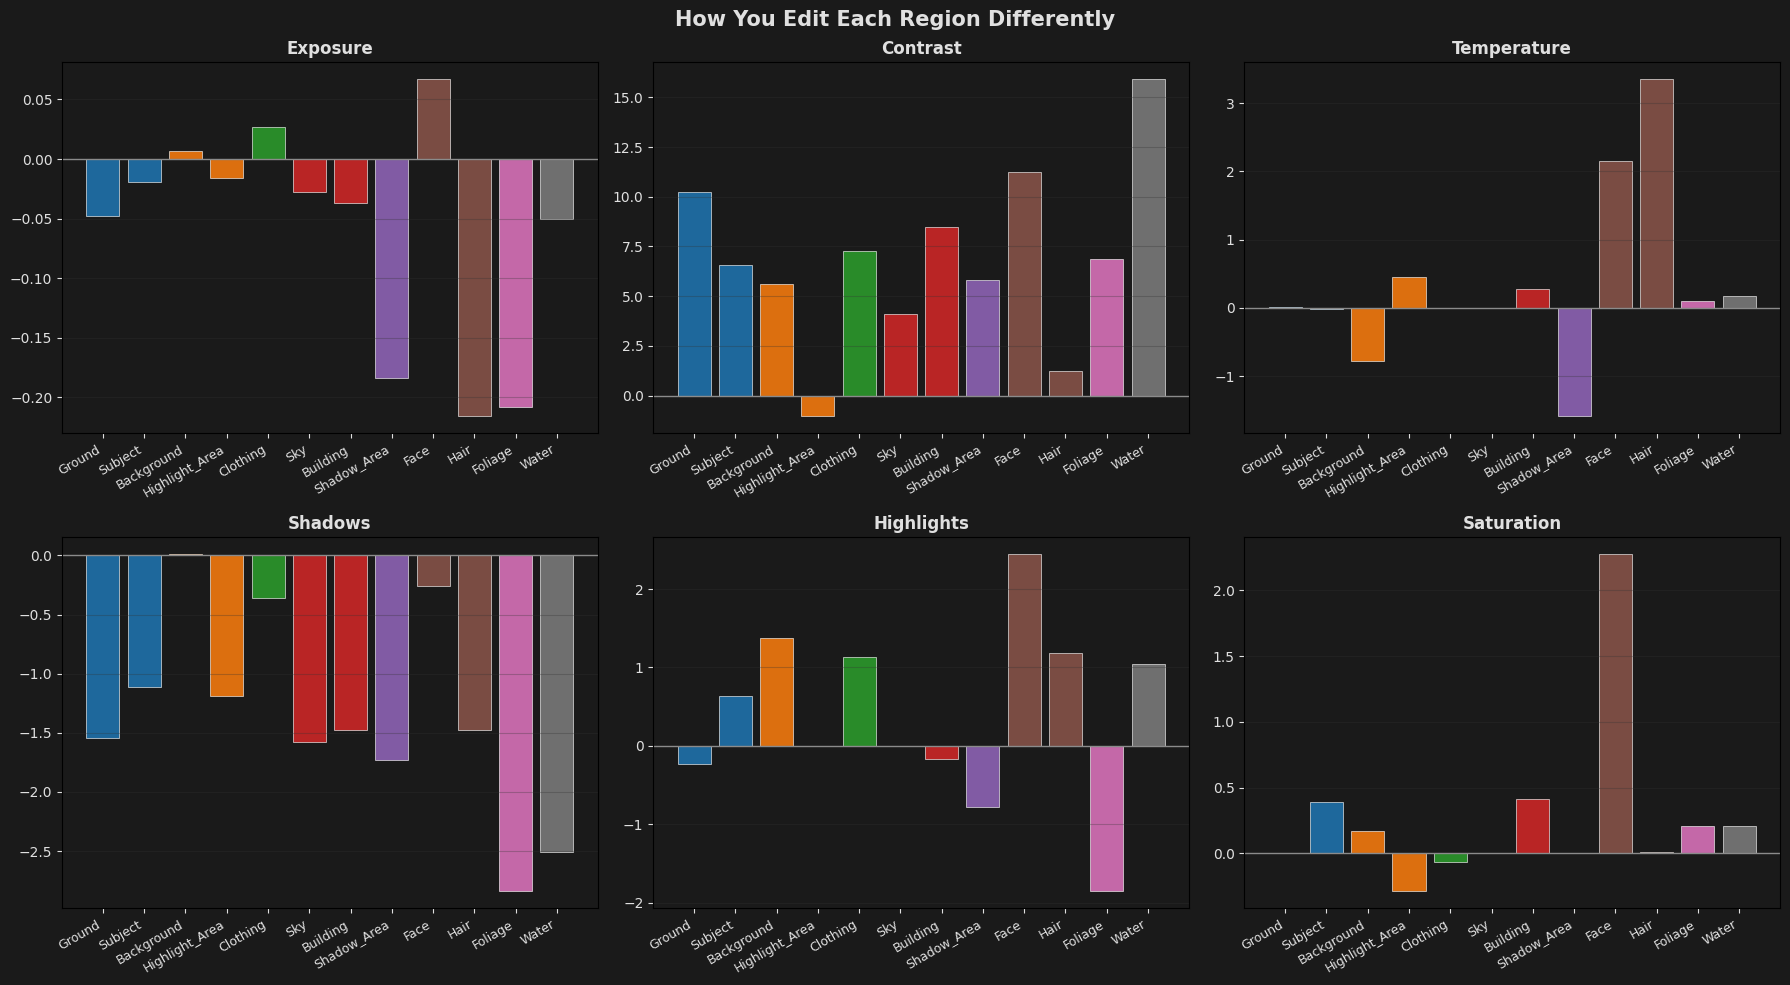


🔍 Regional Editing Patterns:
  Ground (n=192): contrast +10.25, shadows -1.54, highlights -0.23
  Subject (n=163): contrast +6.57, shadows -1.11, highlights +0.64
  Background (n=87): contrast +5.63, highlights +1.38, temperature -0.78
  Highlight_Area (n=29): shadows -1.19, contrast -1.04, temperature +0.45
  Clothing (n=56): contrast +7.26, highlights +1.13, shadows -0.36
  Sky (n=190): contrast +4.11, shadows -1.58, exposure -0.03
  Building (n=168): contrast +8.48, shadows -1.48, saturation +0.41
  Shadow_Area (n=116): contrast +5.79, shadows -1.73, temperature -1.59
  Face (n=18): contrast +11.25, highlights +2.44, saturation +2.27
  Hair (n=17): temperature +3.35, shadows -1.48, contrast +1.26
  Foliage (n=140): contrast +6.88, shadows -2.84, highlights -1.85
  Water (n=59): contrast +15.91, shadows -2.51, highlights +1.04


In [6]:
# Per-region comparison
if data['math_profile']:
    regions = list(data['math_profile'].keys())
    param_names = ['exposure', 'contrast', 'temperature', 'shadows', 'highlights', 'saturation']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=PALETTE['bg'])
    axes = axes.flatten()

    region_colors = plt.cm.tab10(np.linspace(0, 0.7, len(regions)))

    for idx, param in enumerate(param_names):
        ax = axes[idx]
        ax.set_facecolor(PALETTE['bg'])

        values = []
        labels = []
        colors = []
        for i, region in enumerate(regions):
            val = data['math_profile'][region].get('parameters', {}).get(param, 0)
            values.append(val)
            labels.append(region.title())
            colors.append(region_colors[i])

        bars = ax.bar(range(len(regions)), values, color=colors, alpha=0.85,
                      edgecolor='white', linewidth=0.5)
        ax.axhline(0, color=PALETTE['neutral'], linewidth=1)
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(labels, rotation=30, ha='right', color=PALETTE['text'], fontsize=9)
        ax.set_title(param.replace('_', ' ').title(), color=PALETTE['text'],
                     fontsize=12, fontweight='bold')
        ax.tick_params(colors=PALETTE['text'])
        ax.grid(axis='y', color=PALETTE['grid'], alpha=0.3)

    plt.suptitle('How You Edit Each Region Differently', color=PALETTE['text'],
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Narrative
    print("\n🔍 Regional Editing Patterns:")
    for region in regions:
        params = data['math_profile'][region].get('parameters', {})
        sample = data['math_profile'][region].get('sample_size', '?')
        top = sorted(params.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
        shifts = ", ".join([f"{k} {v:+.2f}" for k, v in top])
        print(f"  {region.title()} (n={sample}): {shifts}")
else:
    print("No math profile found.")

## 6. Per-Image Variation: Your Editing Distribution

Not every photo gets the same treatment. This shows the spread of your adjustments across individual images, revealing which parameters you're decisive about and which you adapt per-image.

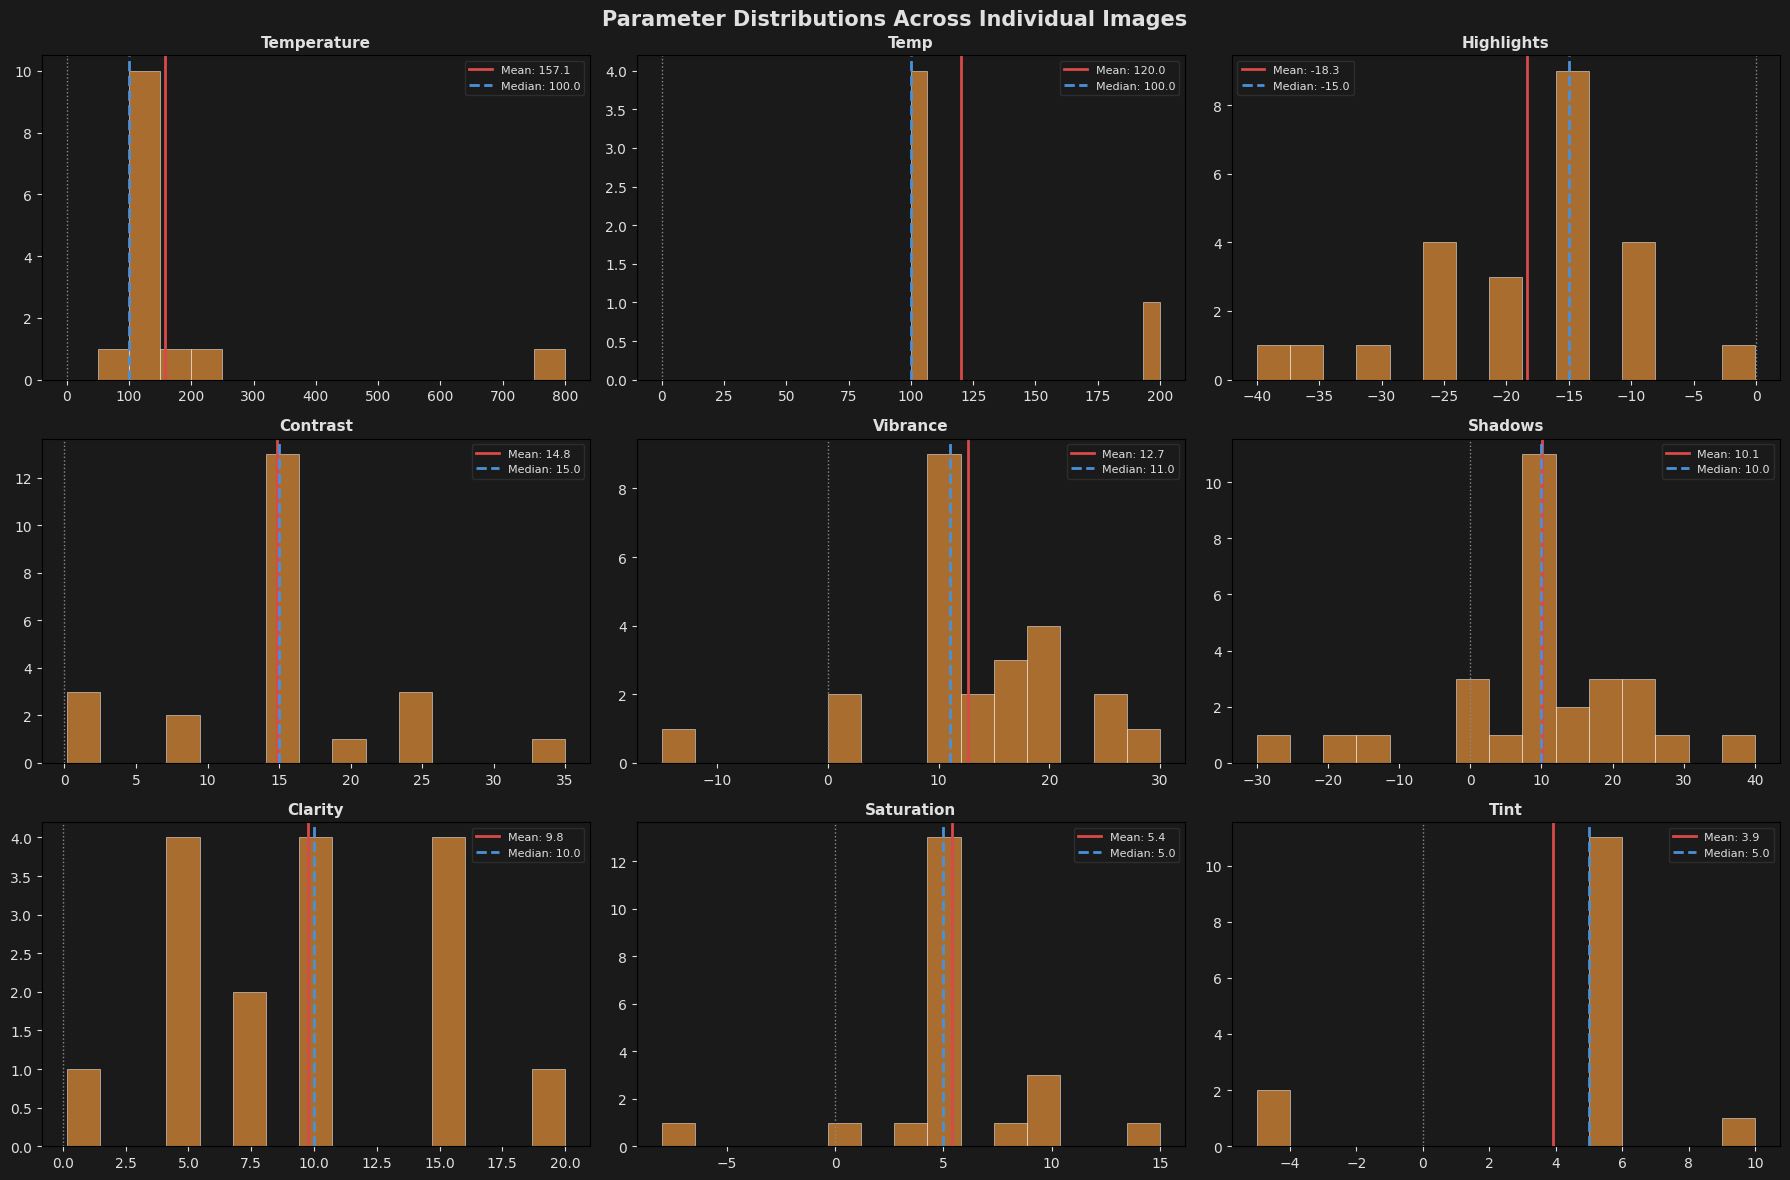


📊 Scene Type Distribution (30 analyzed):
  Daylight Landscape        █████████████████████████████████ (11)
  Portrait                  ██████████████████ (6)
  Night Street              ███████████████ (5)
  Indoor                    ████████████ (4)
  Overcast                  ██████ (2)
  Architecture              ███ (1)
  Backlit                   ███ (1)


In [7]:
# Distribution plots from raw analyses
if data['raw_analyses']:
    # Extract per-image global params
    per_image_params = defaultdict(list)
    scene_per_image = []

    for a in data['raw_analyses']:
        analysis = a.get('analysis', {})
        scene = analysis.get('scene_type', 'unknown')
        scene_per_image.append(scene)

        for key, val in analysis.get('global', {}).items():
            if isinstance(val, (int, float)):
                per_image_params[key].append(val)

    # Pick the most commonly adjusted parameters
    active_params = {k: v for k, v in per_image_params.items()
                     if len(v) >= 5 and np.std(v) > 0.5}
    param_list = sorted(active_params.keys(), key=lambda k: abs(np.mean(active_params[k])), reverse=True)[:9]

    if param_list:
        rows = (len(param_list) + 2) // 3
        fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows), facecolor=PALETTE['bg'])
        axes = axes.flatten()

        for idx, param in enumerate(param_list):
            ax = axes[idx]
            ax.set_facecolor(PALETTE['bg'])
            values = active_params[param]

            # Histogram with KDE-like smooth shape
            ax.hist(values, bins=15, color=PALETTE['warm'], alpha=0.7,
                    edgecolor='white', linewidth=0.5)
            ax.axvline(np.mean(values), color=PALETTE['accent'], linewidth=2, linestyle='-',
                       label=f'Mean: {np.mean(values):.1f}')
            ax.axvline(np.median(values), color=PALETTE['cool'], linewidth=2, linestyle='--',
                       label=f'Median: {np.median(values):.1f}')
            ax.axvline(0, color=PALETTE['neutral'], linewidth=1, linestyle=':')

            ax.set_title(param.replace('_', ' ').title(), color=PALETTE['text'],
                         fontsize=11, fontweight='bold')
            ax.tick_params(colors=PALETTE['text'])
            ax.legend(fontsize=8, facecolor=PALETTE['bg'], edgecolor=PALETTE['grid'],
                      labelcolor=PALETTE['text'])

        # Hide unused axes
        for j in range(len(param_list), len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Parameter Distributions Across Individual Images',
                     color=PALETTE['text'], fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Scene type distribution
        from collections import Counter
        scene_counts = Counter(scene_per_image)
        print(f"\n📊 Scene Type Distribution ({len(data['raw_analyses'])} analyzed):")
        for scene, count in scene_counts.most_common():
            bar = '█' * (count * 3)
            print(f"  {scene.replace('_', ' ').title():<25} {bar} ({count})")
    else:
        print("Not enough variation in the data for distribution plots.")
else:
    print("No raw analyses found. Run Pipeline 02 first.")

## 7. Style Summary Card

A compact summary of your editing identity, or the kind of thing you'd show a user in the web UI after they upload 10+ photos.

In [8]:
# Build a plain-english style summary from all available data
print("=" * 60)
print("  YOUR STYLE PROFILE")
print("=" * 60)

# Overall tendency from LLM profiles
if data['llm_profiles'] and 'overall' in data['llm_profiles']:
    overall = data['llm_profiles']['overall']
    print("\n🎯 GLOBAL TENDENCY")
    tendencies = []

    temp = overall.get('temperature', {})
    if isinstance(temp, dict) and temp.get('mean', 0) > 3:
        tendencies.append("warm tones")
    elif isinstance(temp, dict) and temp.get('mean', 0) < -3:
        tendencies.append("cool tones")

    shadows = overall.get('shadows', {})
    if isinstance(shadows, dict) and shadows.get('mean', 0) > 5:
        tendencies.append("lifted shadows (film-like)")
    elif isinstance(shadows, dict) and shadows.get('mean', 0) < -5:
        tendencies.append("crushed shadows (high contrast)")

    highlights = overall.get('highlights', {})
    if isinstance(highlights, dict) and highlights.get('mean', 0) < -5:
        tendencies.append("compressed highlights (soft rolloff)")

    contrast = overall.get('contrast', {})
    if isinstance(contrast, dict) and contrast.get('mean', 0) > 5:
        tendencies.append("punchy contrast")

    vibrance = overall.get('vibrance', {})
    if isinstance(vibrance, dict) and vibrance.get('mean', 0) > 5:
        tendencies.append("boosted vibrance")

    if tendencies:
        print(f"  Your photos tend toward: {', '.join(tendencies)}")
    else:
        print("  Your edits are subtle — no strong global tendency")

# Tone curve summary
if data['color_profile']:
    print("\n🎞️ TONE CURVE STYLE")
    for region, profile in list(data['color_profile'].items())[:3]:
        tc = profile.get('tone_curve', {})
        if isinstance(tc, dict):
            shadow_lift = tc.get('shadows', 0)
            highlight_comp = tc.get('highlights', 0)
            if shadow_lift > 3 and highlight_comp < -3:
                print(f"  {region.title()}: Classic film curve (lifted shadows, compressed highlights)")
            elif shadow_lift > 3:
                print(f"  {region.title()}: Faded/matte aesthetic (lifted shadows)")
            elif highlight_comp < -3:
                print(f"  {region.title()}: Soft highlight rolloff")
            else:
                print(f"  {region.title()}: Near-neutral curve")

# Color identity
if data['color_profile']:
    print("\n🎨 COLOR IDENTITY")
    # Find the most distinctive color shifts
    for region in list(data['color_profile'].keys())[:1]:  # just the primary region
        mixer = data['color_profile'][region].get('color_mixer', {})
        if isinstance(mixer, dict):
            notable = []
            for color, shifts in mixer.items():
                if isinstance(shifts, dict):
                    for axis in ('h', 's', 'l'):
                        val = shifts.get(axis, 0)
                        if abs(val) > 3:
                            axis_name = {'h': 'hue', 's': 'saturation', 'l': 'luminance'}[axis]
                            direction = 'up' if val > 0 else 'down'
                            notable.append(f"{color} {axis_name} {direction}")
            if notable:
                print(f"  Distinctive color shifts: {', '.join(notable[:5])}")
            else:
                print("  Color grading is subtle — no extreme channel shifts")

# Scene variety
if data['llm_profiles'] and 'by_scene' in data['llm_profiles']:
    scenes = data['llm_profiles']['by_scene']
    print(f"\n📸 SCENE RANGE: {len(scenes)} scene types profiled")
    most_common = max(scenes.items(), key=lambda x: x[1].get('count', 0))
    print(f"  Most photographed: {most_common[0].replace('_', ' ').title()} ({most_common[1]['count']} images)")

# Math profile quality
if data['math_profile']:
    regions = list(data['math_profile'].keys())
    total_samples = sum(d.get('sample_size', 0) for d in data['math_profile'].values())
    print(f"\n📐 PROFILE QUALITY")
    print(f"  {len(regions)} semantic regions profiled from {total_samples} total observations")
    print(f"  Regions: {', '.join(r.title() for r in regions)}")

print("\n" + "=" * 60)
print("  Generated from your 287 paired raw/edited photos")
print("  Profile updates as you add more images to the dataset")
print("=" * 60)

  YOUR STYLE PROFILE

🎯 GLOBAL TENDENCY
  Your photos tend toward: warm tones, lifted shadows (film-like), compressed highlights (soft rolloff), punchy contrast, boosted vibrance

🎞️ TONE CURVE STYLE
  Ground: Near-neutral curve
  Subject: Near-neutral curve
  Background: Near-neutral curve

🎨 COLOR IDENTITY
  Distinctive color shifts: reds hue up, reds saturation up, oranges hue up, oranges saturation up, yellows hue up

📸 SCENE RANGE: 7 scene types profiled
  Most photographed: Daylight Landscape (11 images)

📐 PROFILE QUALITY
  12 semantic regions profiled from 1235 total observations
  Regions: Ground, Subject, Background, Highlight_Area, Clothing, Sky, Building, Shadow_Area, Face, Hair, Foliage, Water

  Generated from your 287 paired raw/edited photos
  Profile updates as you add more images to the dataset


## Operationalization Notes

To turn this into a user-facing feature:

1. **Minimum threshold:** Require 10+ paired uploads before generating a profile card
2. **Extract visualization functions to `shared.py`:** Move `generate_style_summary()`, `plot_tone_curve_fingerprint()`, etc. into shared utilities so the Gradio UI (NB05) can call them
3. **Real-time updates:** After each new upload, re-run the extraction incrementally and update the profile JSON
4. **Comparison mode:** Let users compare their profile against reference styles (e.g., "Your style vs Fuji Classic Chrome")
5. **Export:** Generate a shareable image or PDF of the style card